# Text Detection with Surya

This notebook will demonstrate how to use `Surya` to detect text in an image. Surya is named for the Hindu sun god, who has universal vision. Find out more about Surya [here](https://github.com/VikParuchuri/surya).

## Installation

First, we need to install the `surya-ocr` library. You can install it using pip.

In [ ]:
# Install Surya
!pip install surya-ocr

## Initialize Surya Detector and Recognizer

We will first initialize the detector and recognizer. The detector is used to detect text in an image, and the recognizer is used to recognize the text in the detected regions. For the first time, the library will download the pre-trained models.

In [1]:
from surya.model.recognition.model import load_model as load_recognizer
from surya.model.recognition.processor import (load_processor as load_recognizer_processor,)

recognizer = load_recognizer()
recognizer_processor = load_recognizer_processor()

from surya.model.detection.model import load_model as load_detector
from surya.model.detection.model import load_processor as load_detector_processor

detector = load_detector()
detector_processor = load_detector_processor()

config.json:   0%|          | 0.00/8.05k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/941M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

Loaded recognition model vikp/surya_rec2 on device mps with dtype torch.float16


preprocessor_config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

/Users/nim/Repositories/ocr-skooldio/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/154M [00:00<?, ?B/s]

Loaded detection model vikp/surya_det3 on device mps with dtype torch.float16


preprocessor_config.json:   0%|          | 0.00/675 [00:00<?, ?B/s]

(Optional) We can compile the decoder of the recognizer to speed up the recognition process. This is done by calling the `torch.compile`.

In [2]:
import torch

recognizer.decoder.model = torch.compile(recognizer.decoder.model)

## Load and Display the Image

We will load the our document image and display it using jupyter notebook built-in `display` function.

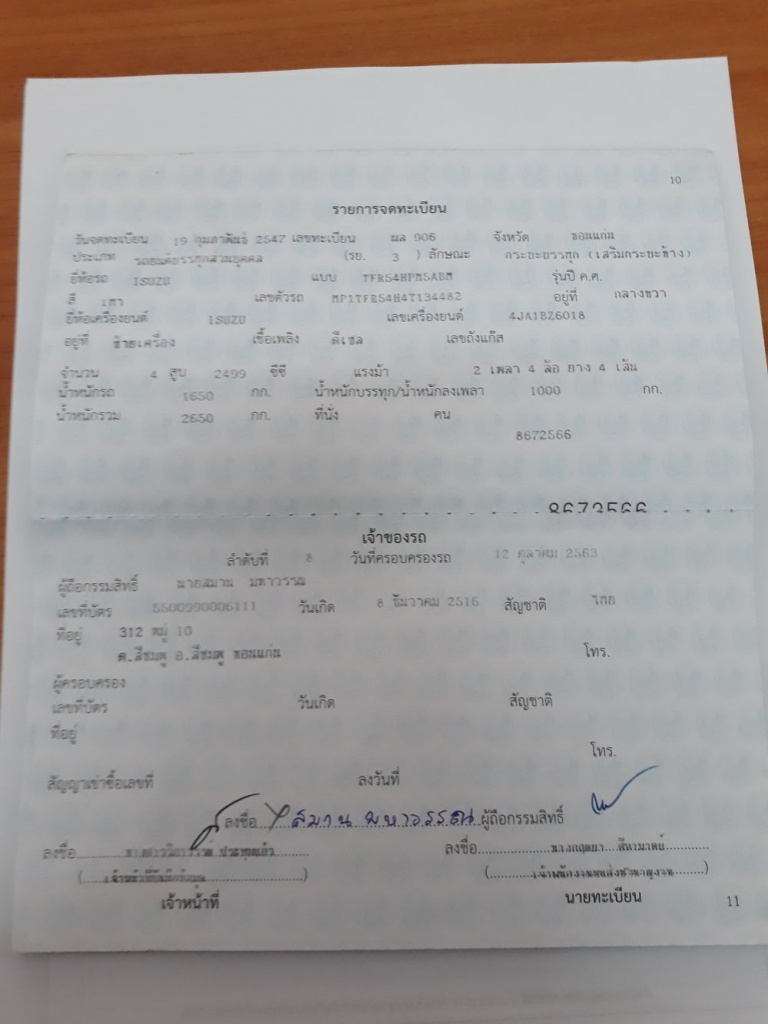

In [2]:
from PIL import Image

# Load the image from a path
image_path = "path/to/image.jpg"
image = Image.open(image_path)

display(image)

## Perform Text Detection and Recognition

We will use the `run_ocr` method to detect and recognize text in the image. This method returns a list of `OCRResult`, where `OCRResult` is the result of the individual document image. This is the structure of `OCRResult`:

```py
# Document level result
class OCRResult(BaseModel):
    text_lines: List[TextLine]
    languages: List[str]
    image_bbox: List[float]
```

which we will use only the `text_lines` attribute. Here is the structure of `TextLine`:

```py
# Text line level result
class TextLine:
    text: str                   # Detected text
    confidence: float           # 0.0 to 1.0
    polygon: List[List[float]]  # [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
```

In [10]:
from surya.ocr import run_ocr
from surya.schema import OCRResult, TextLine

# Define languages to recognize
langs = ["en", "th"]
predictions: list[OCRResult] = run_ocr([image], [langs], detector, detector_processor, recognizer, recognizer_processor)

# Because we only have one image, our result will be in the first element
prediction = predictions[0]
# Unpack the prediction
text_lines: list[TextLine] = prediction.text_lines

# Let's print the first 5 textlines
for idx, text_line in enumerate(text_lines):
    if idx == 5:
        break

    print(f"Textline {idx}: {text_line.text}")
    print(f"Confidence: {text_line.confidence}")
    print(f"Bounding box: {text_line.polygon}")
    print("-" * 80)

Textline 0: ระบบ     รายการจดทะเบียน
Confidence: 0.74755859375
Bounding box: [[274.0, 198.0], [454.0, 198.0], [454.0, 216.0], [274.0, 216.0]]
--------------------------------------------------------------------------------
Textline 1: รับอกชระบิ๊ยน 
Confidence: 0.89453125
Bounding box: [[68.0, 225.0], [695.0, 220.0], [695.0, 263.0], [68.0, 268.0]]
--------------------------------------------------------------------------------
Textline 2: ยีพี่ราคาสตร์ เรื่อง
Confidence: 0.86328125
Bounding box: [[66.0, 266.0], [618.0, 260.0], [618.0, 306.0], [66.0, 312.0]]
--------------------------------------------------------------------------------
Textline 3: อยู่ที่ 
Confidence: 0.962890625
Bounding box: [[548.0, 285.0], [672.0, 281.0], [672.0, 302.0], [549.0, 306.0]]
--------------------------------------------------------------------------------
Textline 4: เทา
Confidence: 0.90380859375
Bounding box: [[78.0, 290.0], [142.0, 294.0], [142.0, 310.0], [78.0, 306.0]]
-------------------------------

## Draw Bounding Boxes and Display the Image with Predictions

We will draw the bounding boxes around the detected text and display the image with the text predictions.

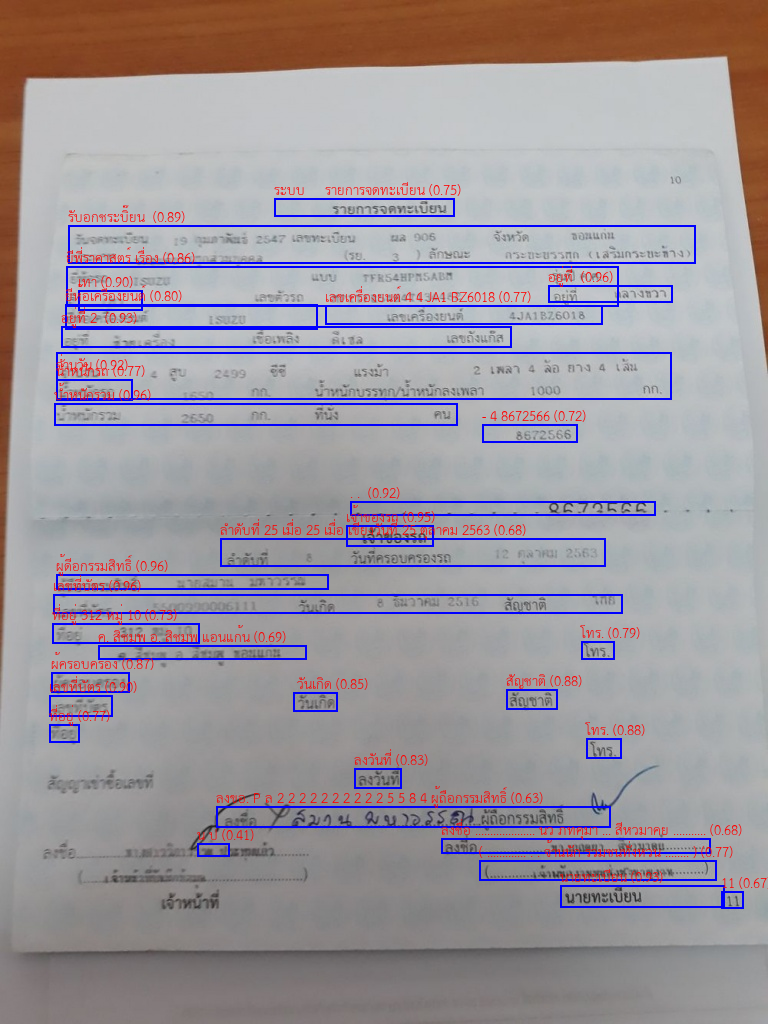

In [12]:
from PIL import ImageDraw, ImageFont
from surya.schema import OCRResult

FONT = ImageFont.truetype("../assets/THSarabun.ttf", size=20)


def draw_boxes(image: Image.Image, result: OCRResult) -> None:
    """Draw bounding boxes and its information on the image."""
    # Create a drawing object
    draw = ImageDraw.Draw(image)

    # Draw each result on the image.
    for text_line in result.text_lines:
        # Unpack the result.
        text = text_line.text
        confidence_score = text_line.confidence
        bbox = text_line.polygon

        # bbox is a four-point coordinate of the bounding box. [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
        # we need to convert it to PIL coordinates to draw the rectangle.
        # which is only two points, top-left and bottom-right. [x1, y1, x2, y2]

        pil_bbox = [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]]

        # 1. Draw the bounding box
        draw.rectangle(pil_bbox, outline="blue", width=2)
        # 2. Draw the text and confidence score e.g. 'Hello (0.72)'
        draw_text = f"{text} ({confidence_score:.2f})"

        # Place text at the top-left of the bounding box and shift it up by 20 pixels
        x = pil_bbox[0]
        y = pil_bbox[1] - 20
        draw.text((x, y), draw_text, fill="red", font=FONT)


# Create a copy of the image to draw on
image_with_boxes = image.copy()
draw_boxes(image_with_boxes, prediction)

display(image_with_boxes)

## Advanced

We can use only the `surya` detector and `surya` recognizer to perform text detection and recognition separately. This is useful when we want to use our own text detection model or our own text recognition model.

### Text Detection with Surya
 This method returns a list of `TextDetectionResult`, where `TextDetectionResult` is the result of the individual document image. This is the structure of `TextDetectionResult`:
```py
class TextDetectionResult(BaseModel):
    bboxes: List[PolygonBox]
    vertical_lines: List[ColumnLine]
    heatmap: Any
    affinity_map: Any
    image_bbox: List[float]
```

which we will use only the `bboxes` attribute. Here is the structure of `PolygonBox`:

```py
class PolygonBox(BaseModel):
    polygon: List[List[float]]
    confidence: Optional[float] = None
```

In [14]:
from surya.detection import batch_text_detection
from surya.schema import TextDetectionResult

bbox_predictions: list[TextDetectionResult] = batch_text_detection([image], detector, detector_processor)

# Because we only have one image, our result will be in the first element
bbox_prediction = bbox_predictions[0]

# Unpack the prediction
bboxes = bbox_prediction.bboxes

# Let's print the first 5 bounding boxes
for idx, bbox in enumerate(bboxes):
    if idx == 5:
        break

    print(f"Bounding box {idx}: {bbox.polygon}")
    print(f"Confidence: {bbox.confidence}")
    print("-" * 80)

Detecting bboxes: 100%|██████████| 1/1 [00:02<00:00,  2.87s/it]


Bounding box 0: [[274, 198], [454, 198], [454, 216], [274, 216]]
Confidence: 0.9615673422813416
--------------------------------------------------------------------------------
Bounding box 1: [[68, 225], [695, 220], [695, 263], [68, 268]]
Confidence: 0.9405013918876648
--------------------------------------------------------------------------------
Bounding box 2: [[66, 266], [618, 260], [618, 306], [66, 312]]
Confidence: 0.904568076133728
--------------------------------------------------------------------------------
Bounding box 3: [[548, 285], [672, 281], [672, 302], [549, 306]]
Confidence: 0.9100701808929443
--------------------------------------------------------------------------------
Bounding box 4: [[78, 290], [142, 294], [142, 310], [78, 306]]
Confidence: 0.7519908547401428
--------------------------------------------------------------------------------


Now we can draw the bounding boxes.

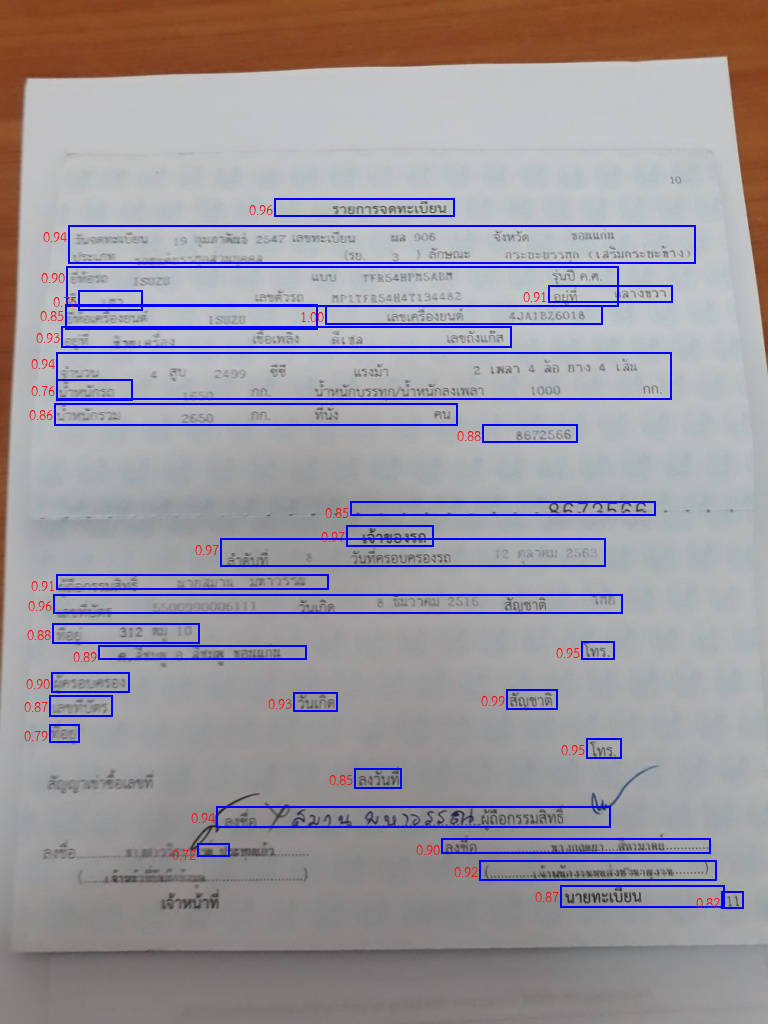

In [16]:
from PIL import ImageDraw

# Create a copy of the image to draw on
image_with_boxes = image.copy()

# Create a drawing object
draw = ImageDraw.Draw(image_with_boxes)

# Draw each region on the image
for bbox in bboxes:
    # Unpack the result.
    confidence_score = bbox.confidence
    bbox = bbox.polygon

    # bbox is a four-point coordinate of the bounding box. [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    # we need to convert it to PIL coordinates to draw the rectangle.
    # which is only two points, top-left and bottom-right. [x1, y1, x2, y2]

    pil_bbox = [bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]]

    # 1. Draw the bounding box
    draw.rectangle(pil_bbox, outline="blue", width=2)
    # 2. Draw the confidence score e.g. '0.72'
    draw_text = f"{confidence_score:.2f}"
    # Shift the text to the left of the bounding box to make it more visible
    draw.text((pil_bbox[0] - 25, pil_bbox[1]), draw_text, fill="red", font=FONT)


display(image_with_boxes)

Now let's crop the detected text regions and perform text recognition using the `surya` recognizer.

In [18]:
# Crop the textboxes from the image
textboxes = []
for bbox in bboxes:
    bbox = bbox.polygon
    # bbox is a four-point coordinate of the bounding box. [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    # we need to convert it to PIL coordinates to draw the rectangle.
    # which is only two points, top-left and bottom-right. [x1, y1, x2, y2]
    textboxes.append(image.crop([bbox[0][0], bbox[0][1], bbox[2][0], bbox[2][1]]))

### Text Recognition with Surya
 This method returns a tuple of `List[str]` and `List[float]`, where the first element is the list of recognized text and the second element is the list of confidence scores.


Text: ระบบ     รายการจดทะเบียน
Confidence: 0.7509765625


--------------------------------------------------------------------------------
Text: รับอลชายเปียน 
Confidence: 0.90869140625


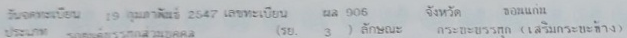

--------------------------------------------------------------------------------
Text: ยีพัทธาติ (Suzuka 1988) 
Confidence: 0.859375


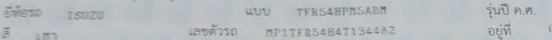

--------------------------------------------------------------------------------
Text: อยู่ที่ 
Confidence: 0.95947265625


--------------------------------------------------------------------------------
Text: น 
Confidence: 0.89697265625


--------------------------------------------------------------------------------


In [23]:
from surya.recognition import batch_recognition
from surya.schema import TextDetectionResult

# The number of languages must match the number of textboxes
# So we need to pass a list of languages for each textbox
languages = [["en", "th"]] * len(textboxes)
text_predictions, confidence_scores = batch_recognition(textboxes, languages, recognizer, recognizer_processor)

# Let's print the first 5 text predictions
for idx, (text, confidence_score, textbox) in enumerate(zip(text_predictions, confidence_scores, textboxes)):
    if idx == 5:
        break

    print(f"Text: {text}")
    print(f"Confidence: {confidence_score}")
    display(textbox)
    print("-" * 80)